# s4e3 kaggle playground series eda



In [1]:
# load pkgs and read in data
import polars as pl
import seaborn as sns

sns.set_theme()

trn = pl.read_csv("./data/train.csv")

In [2]:
trn.shape

(19219, 35)

In [3]:
trn.describe()

describe,id,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0,19219.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",9609.0,709.854675,753.857641,1.8498e6,1.8466e6,1683.987616,95.654665,64.124096,191846.678235,84.808419,128.64738,1459.350747,0.402674,0.596337,76.213122,0.352939,0.409309,0.57452,0.030609,0.614749,0.831652,0.591899,2.473475,1.312667,1.389737,0.102742,-0.138382,0.571902,0.076279,0.059837,0.178573,0.029554,0.025235,0.247828,0.341225
"""std""",5548.191747,531.544189,499.836603,1.9036e6,1.8963e6,3730.319865,177.821382,101.054178,442024.694057,28.800344,14.196976,145.568687,0.490449,0.490644,53.93196,0.318976,0.124143,0.259436,0.047302,0.222391,0.220966,0.48205,0.760575,0.467848,0.405549,0.487681,0.120344,0.332219,0.26545,0.23719,0.383005,0.169358,0.156844,0.431762,0.474133
"""min""",0.0,0.0,4.0,6712.0,6724.0,6.0,2.0,1.0,250.0,0.0,39.0,1227.0,0.0,0.0,40.0,0.0,0.0,0.0083,0.0015,0.0144,0.105,0.0,0.7782,0.301,0.0,-0.9884,-0.885,0.119,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",4804.0,49.0,214.0,657468.0,657502.0,89.0,15.0,14.0,9848.0,70.0,124.0,1358.0,0.0,0.0,40.0,0.0586,0.3175,0.3757,0.0066,0.4516,0.6552,0.0,1.9494,1.0,1.0792,-0.2727,-0.1925,0.2532,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",9609.0,777.0,796.0,1.398169e6,1.398179e6,168.0,25.0,23.0,18238.0,90.0,127.0,1364.0,0.0,1.0,69.0,0.2385,0.4135,0.5454,0.0095,0.6364,0.9643,1.0,2.2279,1.1461,1.3222,0.1111,-0.1426,0.4729,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""75%""",14414.0,1152.0,1165.0,2.368032e6,2.364667e6,653.0,64.0,61.0,67978.0,105.0,135.0,1652.0,1.0,1.0,80.0,0.6561,0.4946,0.8182,0.0191,0.7857,1.0,1.0,2.8149,1.4314,1.7076,0.5294,-0.084,0.9994,0.0,0.0,0.0,0.0,0.0,0.0,1.0
"""max""",19218.0,1705.0,1713.0,1.2987661e7,1.2987692e7,152655.0,7553.0,903.0,1.1591414e7,196.0,253.0,1794.0,1.0,1.0,300.0,0.9952,0.9275,1.0,0.6651,1.0,1.0,1.0,4.5543,2.9973,4.0333,0.9917,0.6421,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [21]:
#get names of cols
nms = trn.columns

targets = nms[(len(nms)-7):len(nms)]

Y = trn[targets]
X = trn.drop(targets)
X = X.drop("id")

## Explore Targets

<Axes: xlabel='variable', ylabel='value'>

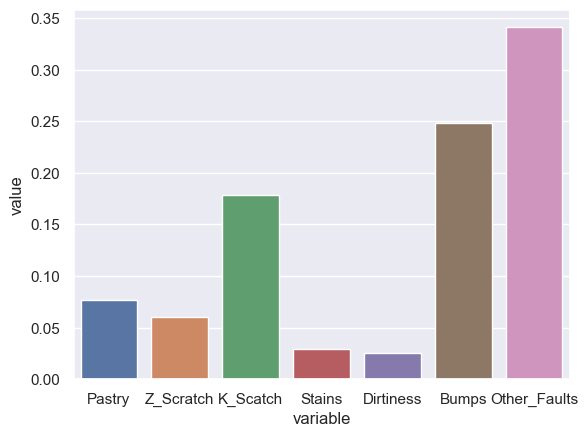

In [15]:
#get the means of each of the possible defects
tar_means = Y.mean(axis=0)

tar_means_long = tar_means.melt()

sns.barplot(data = tar_means_long.to_pandas(), x = "variable", y = "value")

In [23]:
#for each value of y, find the predictors with the highest correlation
def cor_preds(y, X, val):
   tmp = y.select(val) 
   df = pl.concat([tmp, X], how = "horizontal")
   cor_mat = df.corr()
   return cor_mat


In [25]:
tst_cor = cor_preds(Y, X, "Pastry")

tst_cor
#next step is to figure out how to get the highest abs-value corr from this
#isn't hard, just don't feel like doing it right now

Pastry,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.119306,0.108808,-0.015512,-0.016287,-0.101295,-0.104322,-0.064965,-0.09316,-0.004622,-0.08609,0.15867,-0.007322,0.007499,0.080037,-0.019327,-0.133623,-0.150458,-0.139184,-0.10172,0.201774,0.223768,-0.06859,-0.177303,0.036549,0.261302,-0.103424,-0.042299
0.119306,1.0,0.989767,0.016071,0.014247,-0.464759,-0.451961,-0.426514,-0.430073,0.337748,-0.132955,0.30874,0.220151,-0.218122,0.188764,0.167358,-0.175624,0.045635,-0.522112,0.112746,0.460421,0.222109,-0.505024,-0.530728,-0.375324,0.276871,-0.068844,-0.376973
0.108808,0.989767,1.0,0.018909,0.016513,-0.391937,-0.378434,-0.356528,-0.363092,0.275571,-0.129669,0.293466,0.189802,-0.188033,0.164789,0.1298,-0.146167,0.035124,-0.432545,0.095799,0.391743,0.190474,-0.428875,-0.448348,-0.31677,0.237157,-0.079235,-0.319598
-0.015512,0.016071,0.018909,1.0,0.969552,-0.00737,-0.012712,-0.024876,-0.008189,-0.017321,-0.02916,0.016586,0.044781,-0.044328,-0.054389,0.035762,-0.033792,0.033952,0.019685,0.05271,-0.002647,-0.025374,-0.001754,0.015116,-0.023702,-0.044202,-0.023,-0.031511
-0.016287,0.014247,0.016513,0.969552,1.0,-0.007019,-0.012377,-0.024798,-0.007809,-0.018739,-0.028312,0.015735,0.044867,-0.044422,-0.058683,0.034222,-0.032824,0.034552,0.017271,0.051546,-0.001382,-0.023285,-0.000995,0.015624,-0.022941,-0.04249,-0.022869,-0.030345
-0.101295,-0.464759,-0.391937,-0.00737,-0.007019,1.0,0.835079,0.834543,0.797843,-0.622867,0.130499,-0.208256,-0.304635,0.300308,-0.232467,-0.337258,0.269263,0.024658,0.76481,-0.303335,-0.650704,-0.205579,0.77458,0.749731,0.640033,-0.269013,-0.015081,0.542672
-0.104322,-0.451961,-0.378434,-0.012712,-0.012377,0.835079,1.0,0.912579,0.802072,-0.603891,0.158036,-0.20606,-0.300883,0.296467,-0.225757,-0.326388,0.322417,0.050052,0.75247,-0.378672,-0.664781,-0.174615,0.771546,0.750418,0.667441,-0.234969,0.005212,0.561256
-0.064965,-0.426514,-0.356528,-0.024876,-0.024798,0.834543,0.912579,1.0,0.809171,-0.602826,0.160831,-0.188716,-0.304057,0.299557,-0.189628,-0.32095,0.338079,0.003372,0.700036,-0.469092,-0.612157,-0.081225,0.790863,0.705657,0.761117,-0.113968,-0.00565,0.608167
-0.09316,-0.430073,-0.363092,-0.008189,-0.007809,0.797843,0.802072,0.809171,1.0,-0.580857,0.128569,-0.194282,-0.282051,0.278,-0.215082,-0.309055,0.271448,0.031948,0.703912,-0.315125,-0.608297,-0.177048,0.726483,0.698035,0.615651,-0.234625,-0.013845,0.520282
